In [1]:
import numpy as np
import matplotlib.pyplot as plt
from diag_operator_build_wf import *
import matplotlib.colors as colours
import matplotlib.animation as animation
from tqdm.notebook import tqdm
import sys

Computing negativity using coherent states and superpositions of coherent states on the torus as initial states for the kicked rotor

In [2]:
def coherent_state(N, Z, p, q, M = 20):

    # parameters for creating the state
    kappa1 = np.pi/3
    kappa2 = np.pi
    hbar = 1/(2*np.pi*N)

    psi = np.zeros(N, dtype = complex)

    for j in range(N):
        cj = 0.0
        for m in range(-M, M + 1):
            xjm = j/N + kappa2/(2*np.pi*N) - m
            cj += np.exp(1j*(kappa1*m - (xjm/hbar) - (Z * (xjm-q)**2)/(2*hbar)))
        psi[j] = cj * np.exp(-1j*p*q/(2*hbar))
    return psi/np.linalg.norm(psi)

def plot_WF(W, title):
    # plot the wigner function

    vmin = np.min(W)
    vmax = np.max(W)

    norm = colours.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    plt.figure(figsize=(16,7))
    plt.imshow(W, cmap='RdBu_r', origin='lower', norm = norm ,interpolation='nearest')
    plt.colorbar(label='Wigner value')
    plt.xlabel('a2')
    plt.ylabel('a1')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def time_evol(U, n, psi_initial):

    psi0 = psi_initial
    for i in range(1, n):
        psi = U@psi0
        psi0 = psi

    return psi

In [3]:
# making a function that will compute negativities and return it.
# this function will use the coherent state function and create initial states as well

def negativity(N, Z, p, q, dep_param, choice = 1):

    negativity = np.zeros(len(dep_param))

In [4]:
N = 1009
n = 100

neg1 = np.zeros(n)

psi0 = coherent_state(N, -0.1j, 0.5, 0.5)
W0 = wigner_function(np.outer(psi0, psi0.conj())).real
neg1[0] = np.sum((np.abs(W0)-W0))/2

for i in range(1, n):
    U = diagonalize_floquet_operator(N, 0, 0, 0.4)
    psi = U@psi0
    rho = np.outer(psi, psi.conj())
    W = wigner_function(rho).real  
    neg1[i] = np.sum((np.abs(W) - W))/2
    """if i%10==0:
        plot_WF(W, f"{i}")"""
    psi0 = psi

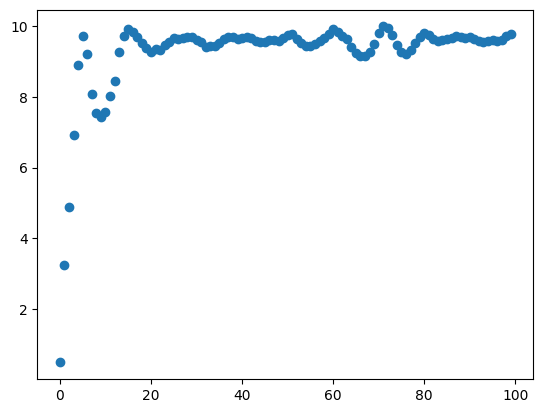

In [5]:
plt.scatter(np.arange(n), neg1)
plt.show()

In [6]:
def system_size_dependence(sizes, kappa, Z = -0.05j):

    neg = np.zeros(len(sizes))
    for i in range(len(sizes)):
        U = diagonalize_floquet_operator(sizes[i], 0, 0, kappa)
        psi0 = coherent_state(sizes[i], Z, 0.5, 0.5)
        psi = time_evol(U, 10, psi0)
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real
        neg[i] = np.sum(np.abs(W) - W)/2
        psi0 = psi

    return neg

In [7]:
sys_sizes = np.array([11, 53, 107, 281, 479, 659, 733, 859, 953, 1009, 1103, 1277, 1321, 1487, 1619, 1783, 1933])

n1 = system_size_dependence(sys_sizes, 0.01)
n2 = system_size_dependence(sys_sizes, 1)
n3 = system_size_dependence(sys_sizes, 6)

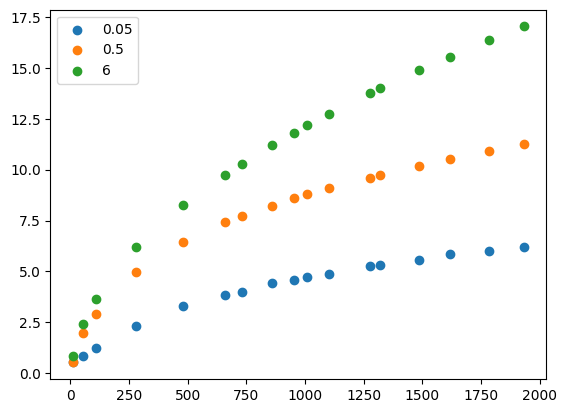

In [8]:
plt.scatter(sys_sizes, system_size_dependence(sys_sizes, 0.05), label = "0.05")
plt.scatter(sys_sizes, system_size_dependence(sys_sizes, 0.5), label = "0.5")
plt.scatter(sys_sizes, n3, label = "6")

plt.legend()
plt.show()

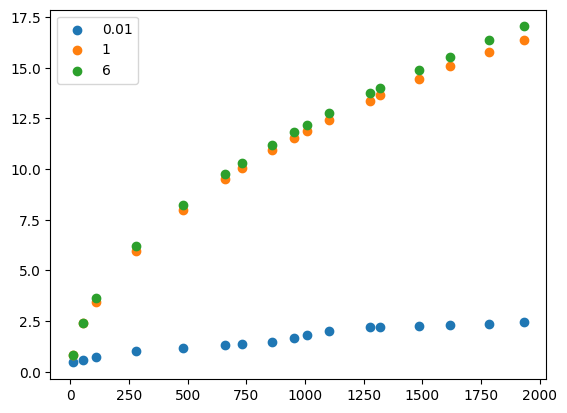

In [9]:
plt.scatter(sys_sizes, n1, label = "0.01")
plt.scatter(sys_sizes, n2, label = "1")
plt.scatter(sys_sizes, n3, label = "6")
plt.legend()
plt.show()

In [10]:
Z = -0.05j

sys_sizes = np.array([11, 53, 107, 281, 479, 659, 733, 859, 953, 1009, 1103, 1277, 1321, 1487, 1619, 1783, 1933])
neg2 = np.zeros(len(sys_sizes))
neg3 = np.zeros(len(sys_sizes))

for i in range(len(sys_sizes)):
    U = diagonalize_floquet_operator(sys_sizes[i], 0, 0, 0.1)
    psi0 = coherent_state(sys_sizes[i], Z, 0.5, 0.5)
    psi = time_evol(U, 50, psi0)
    rho = np.outer(psi, psi.conj())
    W = wigner_function(rho).real
    neg2[i] = np.sum(np.abs(W) - W)/2
    psi0 = psi

for i in range(len(sys_sizes)):
    psi0 = coherent_state(sys_sizes[i], Z, 0.5, 0.5)
    rho = np.outer(psi, psi.conj())
    W = wigner_function(rho).real
    neg3[i] = np.sum(np.abs(W) - W)/2
    psi0 = psi

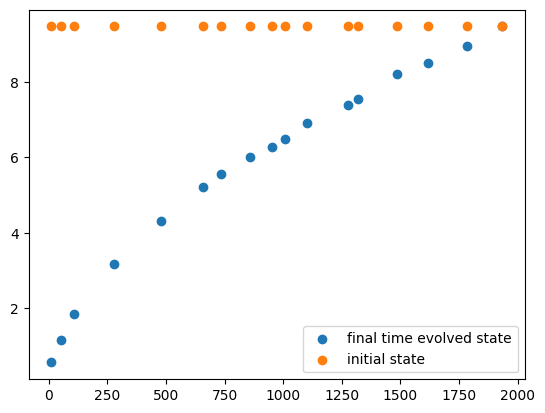

In [11]:
plt.scatter(sys_sizes, neg2, label = "final time evolved state")
plt.scatter(sys_sizes, neg3, label = "initial state")
plt.legend()
plt.show()

In [12]:
# check with coupling constant

#coupling = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.5, 3, 4, 4.5, 5, 6, 7, 8, 9, 10])

coupling = np.linspace(0.1, 6, 50)
neg4 = np.zeros(len(coupling))

for i in range(len(coupling)):
    U = diagonalize_floquet_operator(N, 0, 0, coupling[i])
    psi0 = coherent_state(N, Z, 0.5, 0.5)
    psi = time_evol(U, 10, psi0)
    rho = np.outer(psi, psi.conj())
    W = wigner_function(rho).real
    neg4[i] = np.sum(np.abs(W) - W)/2

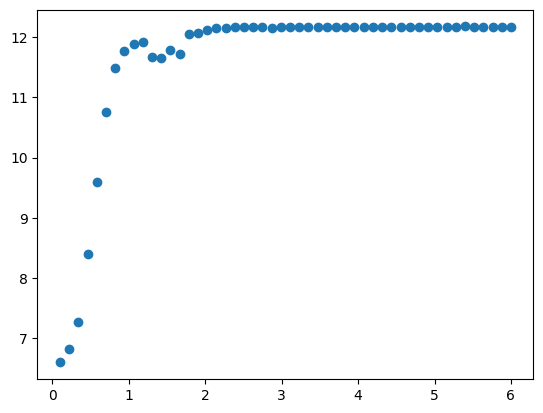

In [13]:
plt.scatter(coupling, neg4)
plt.show()

Initial state is one which is localized in a certain part of the torus in the position basis.

In [2]:
def localized_pos_state(size):
    psi0 = np.zeros(size, dtype = complex)
    beg = int(0.35*size)
    end = int(0.65*size)
    psi0[beg:end] = np.random.uniform(-1, 1, end-beg) + 1j * np.random.uniform(-1, 1, end-beg)
    psi0 /= np.linalg.norm(psi0)
    
    return psi0

def time_evol(U, n, psi_initial):

    psi0 = psi_initial
    for i in range(1, n):
        psi = U@psi0
        psi0 = psi

    return psi

### System Size

In [ ]:
def system_size_dependence(sizes, kappa):

    neg = np.zeros(len(sizes))
    for i in range(len(sizes)):
        U = diagonalize_floquet_operator(sizes[i], 0, 0, kappa)
        psi0 = localized_pos_state(sizes[i])
        psi = time_evol(U, 10, psi0)
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real
        neg[i] = np.sum(np.abs(W) - W)/2
        psi0 = psi

    return neg

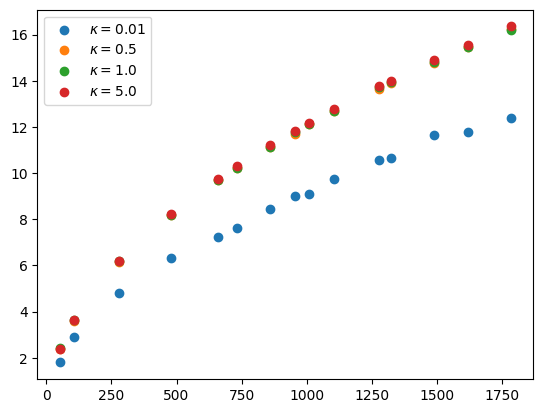

In [6]:
sys_sizes = np.array([53, 107, 281, 479, 659, 733, 859, 953, 1009, 1103, 1277, 1321, 1487, 1619, 1783])
kappa = np.array([0.01, 0.5, 1, 5])

for k in kappa:
    neg_pos = system_size_dependence(sys_sizes, k)
    plt.scatter(sys_sizes, neg_pos, label = r"$\kappa = $"+f"{k}")
plt.legend()
plt.show()

### Time evolution

In [ ]:
def time_evol_negativity(N, n, k):

    neg1 = np.zeros(n)

    psi0 = localized_pos_state(N)
    W0 = wigner_function(np.outer(psi0, psi0.conj())).real
    neg1[0] = np.sum((np.abs(W0)-W0))/2

    for i in range(1, n):
        U = diagonalize_floquet_operator(N, 0, 0, k)
        psi = U@psi0
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real  
        neg1[i] = np.sum((np.abs(W) - W))/2
        psi0 = psi

    return neg1

In [25]:
N = 1009
n = 50
t = np.arange(n)

neg_t1 = time_evol_negativity(N,n, 0.01)
neg_t2 = time_evol_negativity(N,n, 0.1)
neg_t3 = time_evol_negativity(N,n, 1.2)
neg_t4 = time_evol_negativity(N,n, 2.5)
neg_t5 = time_evol_negativity(N,n, 5)

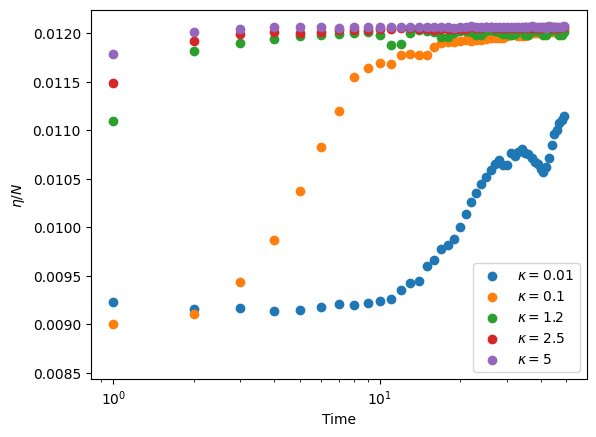

In [93]:
plt.scatter((t), (neg_t1)/N, label = r"$\kappa = 0.01$")
plt.scatter((t), (neg_t2)/N, label = r"$\kappa = 0.1$")
plt.scatter((t), (neg_t3)/N, label = r"$\kappa = 1.2$")
plt.scatter((t), (neg_t4)/N, label = r"$\kappa = 2.5$")
plt.scatter((t), (neg_t5)/N, label = r"$\kappa = 5$")

plt.xlabel("Time")
plt.ylabel(r"$\eta/N$")
plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.show()

In [31]:
del_t = np.arange(n)[1:]
growth_t1 = np.diff(neg_t1)
growth_t2 = np.diff(neg_t2)
growth_t3 = np.diff(neg_t3)
growth_t4 = np.diff(neg_t4)
growth_t5 = np.diff(neg_t5)

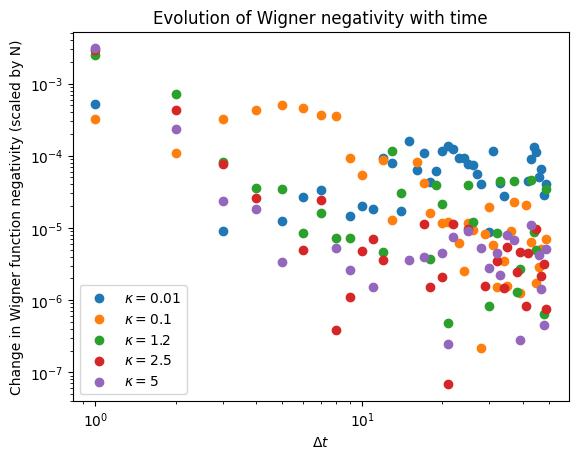

In [36]:
plt.scatter((del_t), (growth_t1)/N, label = r"$\kappa = 0.01$")
plt.scatter((del_t), (growth_t2)/N, label = r"$\kappa = 0.1$")
plt.scatter((del_t), (growth_t3)/N, label = r"$\kappa = 1.2$")
plt.scatter((del_t), (growth_t4)/N, label = r"$\kappa = 2.5$")
plt.scatter((del_t), (growth_t5)/N, label = r"$\kappa = 5$")

plt.xlabel(r"$\Delta t$")
plt.ylabel("Change in Wigner function negativity (scaled by N)")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title("Evolution of Wigner negativity with time")
plt.legend()
plt.show()

### Coupling Constant

In [84]:
def coupling_dependence(N, coupling):

    neg = np.zeros(len(coupling))
    for i, g in enumerate(tqdm(range(len(coupling)), desc="coupling")):
        U = diagonalize_floquet_operator(N, 0, 0, coupling[i])
        psi0 = localized_pos_state(N)
        psi = time_evol(U, 10, psi0)
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real
        neg[i] = np.sum(np.abs(W) - W)/2
        psi0 = psi

    return neg

In [ ]:
kappas = np.array([0.01, 0.05, 0.1, 0.2, 0.4, 0.5, 1, 1.5, 2.5, 3, 4, 5, 6])
neg_K1 = coupling_dependence(281, kappas)
neg_K2 = coupling_dependence(659, kappas)
neg_K3 = coupling_dependence(953, kappas)
neg_K4 = coupling_dependence(1009, kappas)

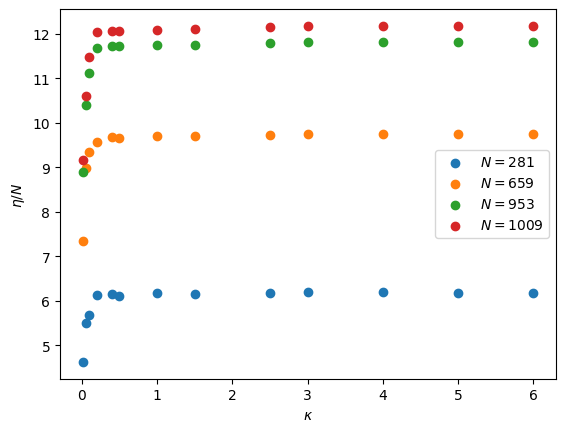

In [42]:
plt.scatter(kappas, (neg_K1), label = r"$N = 281$")
plt.scatter(kappas, (neg_K2), label = r"$N = 659$")
plt.scatter(kappas, (neg_K3), label = r"$N = 953$")
plt.scatter(kappas, (neg_K4), label = r"$N = 1009$")

plt.xlabel(r"$\kappa$")
plt.ylabel(r"$\eta/N$")
plt.legend()
plt.show()

In [87]:
# check finer details with coupling constant to check at which point the asymptotic behaviour arises

kappa_finer = np.linspace(0.01, 5, 1000)
neg_kappa = coupling_dependence(N, kappa_finer)

coupling: 100%|██████████| 1000/1000 [24:31<00:00,  1.47s/it]


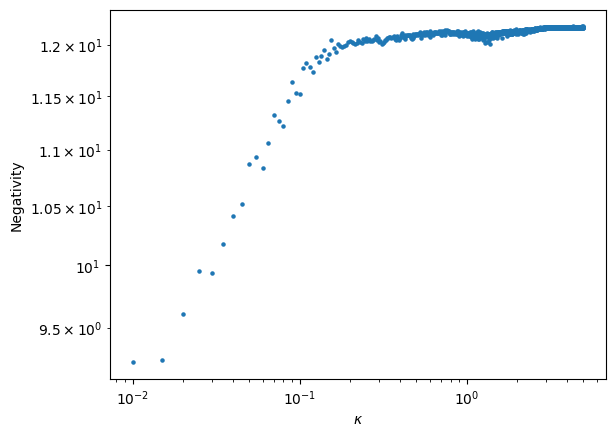

In [89]:
plt.scatter(kappa_finer, neg_kappa, s = 5)
plt.xlabel(r"$\kappa$")
plt.ylabel("Negativity")
plt.xscale('log')
plt.yscale('log')
plt.show()

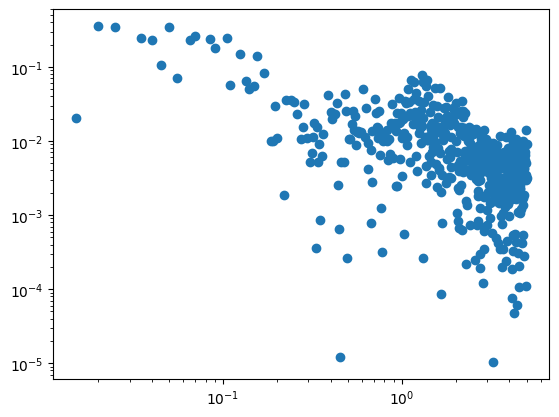

In [91]:
del_neg_kappa = np.diff(neg_kappa)
plt.scatter(kappa_finer[1:], del_neg_kappa)
plt.xscale('log')
plt.yscale('log')
plt.show()

### $\alpha$ and $\beta$ dependence

In [6]:
def time_evol_symmetry_negativity(N, n, k, alpha, beta):

    neg1 = np.zeros(n)

    psi0 = localized_pos_state(N)
    W0 = wigner_function(np.outer(psi0, psi0.conj())).real
    neg1[0] = np.sum((np.abs(W0)-W0))/2

    for i in range(1, n):
        U = diagonalize_floquet_operator(N, alpha, beta, k)
        psi = U@psi0
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real  
        neg1[i] = np.sum((np.abs(W) - W))/2
        psi0 = psi

    return neg1

def alpha_beta_dependence(alphas, betas, k, N, n):
    neg = np.zeros((len(alphas), len(betas)))

    pbar = tqdm(total=len(alphas) * len(betas),desc=r"$(\alpha,\beta)$",position=0,leave=True,file=sys.stdout)

    for i in range(len(alphas)):
        for j in range(len(betas)):
            neg[i, j] = time_evol_symmetry_negativity(N, n, k, alphas[i], betas[j])[-1]
            pbar.update(1)

    pbar.close()

    return neg

In [25]:
alphas = np.round(np.linspace(0, 1, 101),3)
betas = alphas.copy()

neg = alpha_beta_dependence(alphas, betas, 0.01, 107, 10)

$(\alpha,\beta)$:   0%|          | 0/10201 [00:00<?, ?it/s]

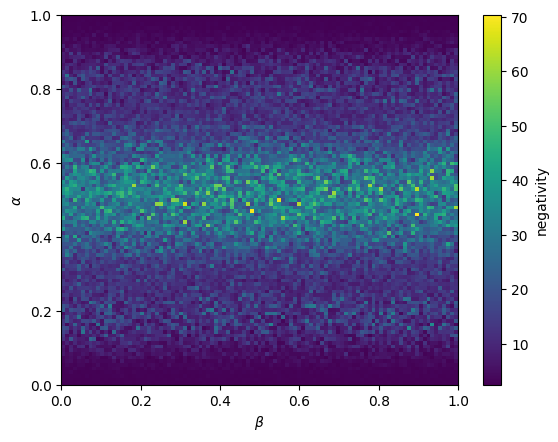

In [26]:
plt.imshow(neg,origin="lower",aspect="auto",extent=[betas[0], betas[-1], alphas[0], alphas[-1]],cmap="viridis")
plt.colorbar(label="negativity")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\alpha$")
plt.show()

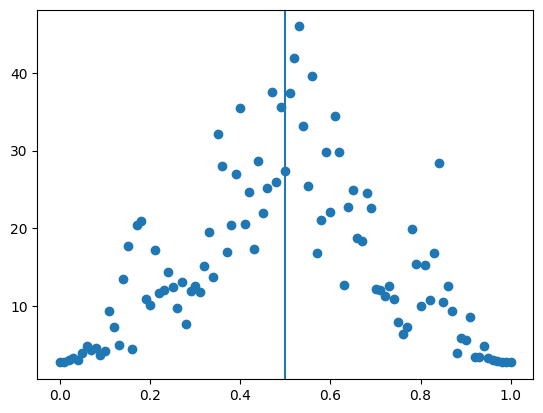

In [34]:
plt.scatter(alphas, neg[:, 1])
plt.axvline(0.5)
plt.show()

In [20]:
def localized_state(size):
    psi0 = np.zeros(size, dtype = complex)
    beg = int(0.8*size)
    end = int(0.85*size)
    psi0[beg:end] = np.random.uniform(-1, 1, end-beg) + 1j * np.random.uniform(-1, 1, end-beg)
    psi0 /= np.linalg.norm(psi0)
    
    return psi0

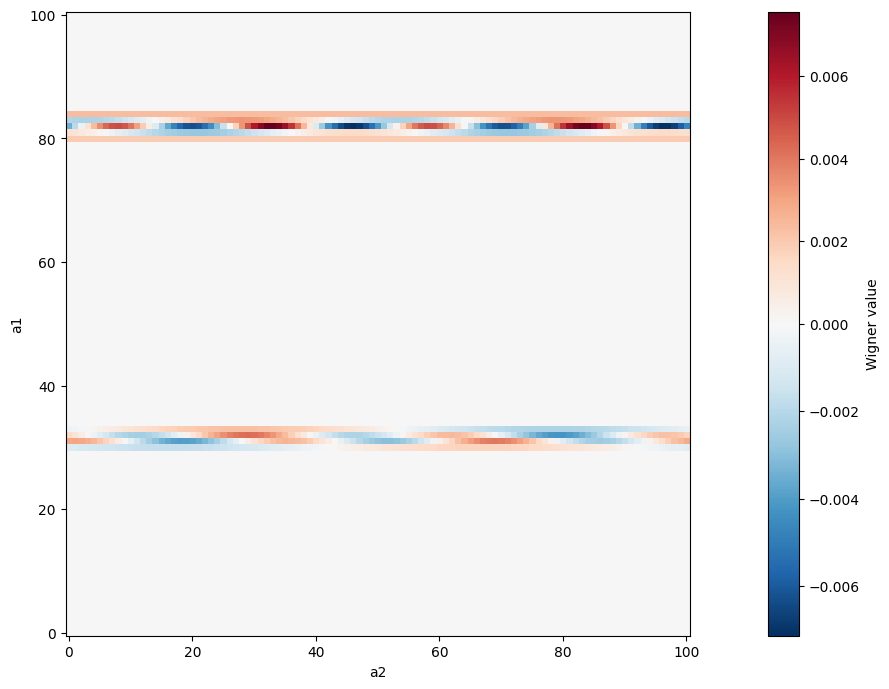

In [23]:
plot_WF(wigner_function(np.outer(localized_state(101), localized_state(101).conj())).real, "")